Using device: cpu


100%|██████████| 170M/170M [03:00<00:00, 943kB/s]  


Training images: 50000
Testing images: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Training with SGD + Momentum
Epoch 1/10: Loss = 1.6979, Accuracy = 40.29%
Epoch 2/10: Loss = 1.4835, Accuracy = 47.97%
Epoch 3/10: Loss = 1.3871, Accuracy = 51.57%
Epoch 4/10: Loss = 1.3176, Accuracy = 54.18%
Epoch 5/10: Loss = 1.2588, Accuracy = 56.24%
Epoch 6/10: Loss = 1.2082, Accuracy = 57.93%
Epoch 7/10: Loss = 1.1590, Accuracy = 59.82%
Epoch 8/10: Loss = 1.1194, Accuracy = 61.20%
Epoch 9/10: Loss = 1.0838, Accuracy = 62.55%
Epoch 10/10: Loss = 1.0451, Accuracy = 63.67%

Training with Adam
Epoch 1/10: Loss = 1.6347, Accuracy = 42.75%
Epoch 2/10: Loss = 1.4365, Accuracy = 49.91%
Epoch 3/10: Loss = 1.3467, Accuracy = 53.32%
Epoch 4/10: Loss = 1.2768, Accuracy = 55.23%
Epoch 5/10: Loss = 1.2096, Accuracy = 57.83%
Epoch 6/10: Loss = 1.1626, Accuracy = 59.58%
Epoch 7/10: Loss = 1.1046, Accuracy = 61.87%
Epoch 8/10: Loss = 1.0606, Accuracy = 6

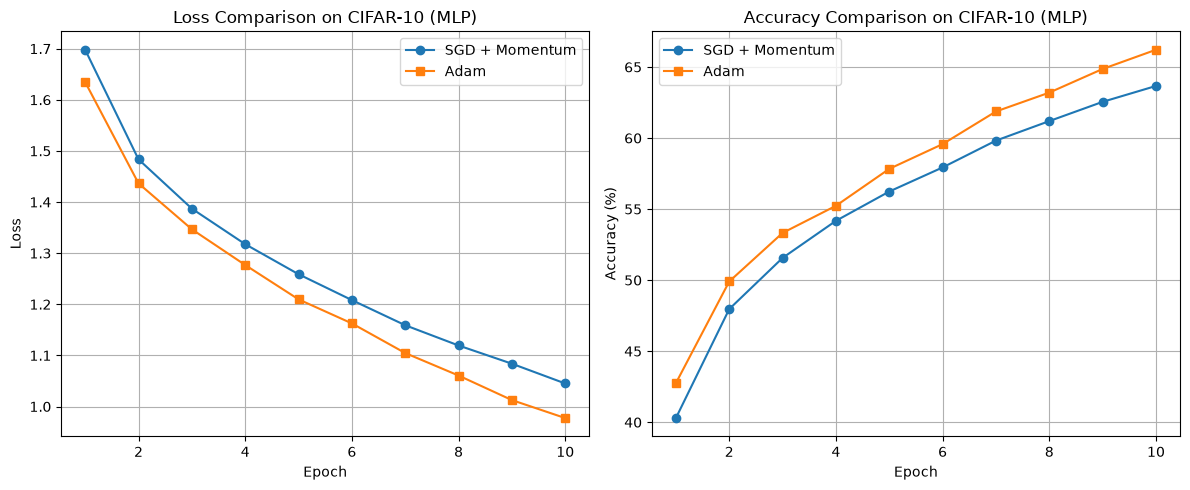

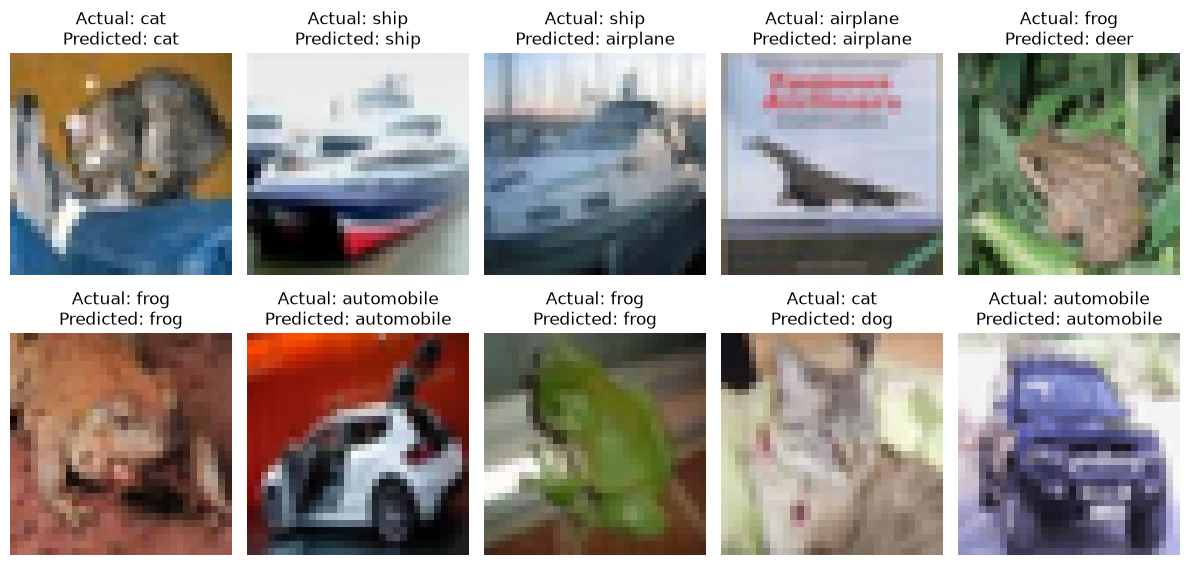


Experiment 3 Completed Successfully!


In [3]:

# EX 3: COMPARISON OF SGD WITH MOMENTUM VS ADAM OPTIMIZER
# Dataset: CIFAR-10

# Step 1: Import Necessary Libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import copy

# Step 2: Set Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Step 3: Load and Preprocess CIFAR-10 Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True,
    num_workers=0
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

classes = trainset.classes

print("Training images:", len(trainset))
print("Testing images:", len(testset))
print("Classes:", classes)

# Step 4: Define MLP Model
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(3 * 32 * 32, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

# Step 5: Define Training Function
def train(model, optimizer, epochs=10):
    model.to(device)
    loss_fn = nn.CrossEntropyLoss()

    losses = []
    accuracies = []

    for epoch in range(epochs):
        total_loss = 0.0
        correct = 0
        total = 0

        model.train()

        for imgs, labels in trainloader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = loss_fn(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * labels.size(0)

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        avg_loss = total_loss / total
        accuracy = 100.0 * correct / total

        losses.append(avg_loss)
        accuracies.append(accuracy)

        print(
            f"Epoch {epoch + 1}/{epochs}: "
            f"Loss = {avg_loss:.4f}, "
            f"Accuracy = {accuracy:.2f}%"
        )

    return losses, accuracies

# Step 6: Define Evaluation Function
def evaluate(model):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0.0
    loss_fn = nn.CrossEntropyLoss()

    with torch.no_grad():
        for imgs, labels in testloader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = loss_fn(outputs, labels)

            total_loss += loss.item() * labels.size(0)
            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_loss = total_loss / total
    test_accuracy = 100.0 * correct / total

    return test_loss, test_accuracy

# Step 7: Initialize Models with the Same Weights
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

base_model = MLP()
initial_weights = copy.deepcopy(base_model.state_dict())

model_sgd = MLP().to(device)
model_sgd.load_state_dict(initial_weights)

model_adam = MLP().to(device)
model_adam.load_state_dict(initial_weights)

# Step 8: Train with SGD + Momentum
epochs = 10

print("\nTraining with SGD + Momentum")

sgd = optim.SGD(
    model_sgd.parameters(),
    lr=0.01,
    momentum=0.9
)

losses_sgd, acc_sgd = train(model_sgd, sgd, epochs)

# Step 9: Train with Adam
print("\nTraining with Adam")

adam = optim.Adam(
    model_adam.parameters(),
    lr=0.001
)

losses_adam, acc_adam = train(model_adam, adam, epochs)

# Step 10: Evaluate Both Models
sgd_test_loss, sgd_test_acc = evaluate(model_sgd)
adam_test_loss, adam_test_acc = evaluate(model_adam)

print("\nFinal Model Comparison")
print("-" * 45)
print(f"SGD + Momentum Test Loss: {sgd_test_loss:.4f}")
print(f"SGD + Momentum Test Accuracy: {sgd_test_acc:.2f}%")
print("-" * 45)
print(f"Adam Test Loss: {adam_test_loss:.4f}")
print(f"Adam Test Accuracy: {adam_test_acc:.2f}%")

# Step 11: Visualize Loss Comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), losses_sgd, marker='o',
         label="SGD + Momentum")
plt.plot(range(1, epochs + 1), losses_adam, marker='s',
         label="Adam")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Comparison on CIFAR-10 (MLP)")
plt.legend()
plt.grid(True)

# Step 12: Visualize Accuracy Comparison
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), acc_sgd, marker='o',
         label="SGD + Momentum")
plt.plot(range(1, epochs + 1), acc_adam, marker='s',
         label="Adam")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison on CIFAR-10 (MLP)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Step 13: Display Sample Predictions
model = model_adam
model.eval()

images, labels = next(iter(testloader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    predictions = outputs.argmax(dim=1).cpu()

plt.figure(figsize=(12, 6))

for i in range(10):
    img = images[i].cpu().numpy().transpose(1, 2, 0)
    img = img * 0.5 + 0.5
    img = np.clip(img, 0, 1)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(
        f"Actual: {classes[labels[i]]}\n"
        f"Predicted: {classes[predictions[i]]}"
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

print("\nExperiment 3 Completed Successfully!")